<a href="https://colab.research.google.com/github/codeAntariksh/Audio-Deepfake-Detection/blob/main/AudioDeepfakeModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/asvpoof-2019-dataset")

print("Path to dataset files:", path)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve
from scipy import signal as sp_signal
from scipy.fftpack import dct
from scipy.interpolate import interp1d
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Libraries loaded
Device: cuda


In [ ]:
import pandas as pd
print(pd.__version__)

2.2.2


## Data Paths

In [ ]:
DATA_ROOT = path + "/LA/LA"

TRAIN_PROTO = os.path.join(
    DATA_ROOT,
    "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
)

DEV_PROTO = os.path.join(
    DATA_ROOT,
    "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt"
)

TEST_PROTO = os.path.join(
    DATA_ROOT,
    "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt"
)

TRAIN_DIR = os.path.join(DATA_ROOT,"ASVspoof2019_LA_train/flac")
DEV_DIR   = os.path.join(DATA_ROOT,"ASVspoof2019_LA_dev/flac")
TEST_DIR  = os.path.join(DATA_ROOT,"ASVspoof2019_LA_eval/flac")

SAMPLE_RATE = 16000
HOP_LENGTH = 160
N_FRAMES = 750

BATCH_SIZE = 64
EPOCHS = 12
LR = 1e-4

print("Dataset configured")

Dataset configured


### Dataset Statistics

In [ ]:
# =============================================================================
# DATASET STATISTICS (COUNT FROM PROTOCOL FILES)
# =============================================================================

def count_dataset(proto_file):

    total = 0
    bonafide = 0
    spoof = 0
    attacks = {}

    with open(proto_file, "r") as f:

        for line in f:

            parts = line.strip().split()

            attack = parts[2]
            label = parts[4]

            total += 1

            if label == "bonafide":
                bonafide += 1
            else:
                spoof += 1

                if attack not in attacks:
                    attacks[attack] = 0

                attacks[attack] += 1

    return total, bonafide, spoof, attacks


# Count train and dev sets
train_total, train_bona, train_spoof, train_attacks = count_dataset(TRAIN_PROTO)
dev_total, dev_bona, dev_spoof, dev_attacks = count_dataset(DEV_PROTO)

print("\n================ DATASET STATISTICS ================")

print("\nTRAIN SET")
print("Total samples:", train_total)
print("Bonafide:", train_bona)
print("Spoof:", train_spoof)

print("\nDEV SET")
print("Total samples:", dev_total)
print("Bonafide:", dev_bona)
print("Spoof:", dev_spoof)

print("\nATTACK DISTRIBUTION (TRAIN)")
for k,v in sorted(train_attacks.items()):
    print(k,":",v)

print("\nATTACK DISTRIBUTION (DEV)")
for k,v in sorted(dev_attacks.items()):
    print(k,":",v)


================ DATASET STATISTICS ================

TRAIN SET
Total samples: 25380
Bonafide: 2580
Spoof: 22800

DEV SET
Total samples: 24844
Bonafide: 2548
Spoof: 22296

ATTACK DISTRIBUTION (TRAIN)
- : 22800

ATTACK DISTRIBUTION (DEV)
- : 22296


# MFCC Feature Extractor


In [ ]:
# =============================================================================
# BLOCK 3: MFCC FEATURE EXTRACTOR
# =============================================================================

class MFCCExtractor:

    def __init__(self):

        self.mfcc = torchaudio.transforms.MFCC(
            sample_rate=SAMPLE_RATE,
            n_mfcc=13,
            melkwargs={
                "n_fft":512,
                "hop_length":HOP_LENGTH,
                "win_length":400,
                "n_mels":26
            }
        )

    def extract(self,wave):

        mfcc = self.mfcc(wave)

        delta = torchaudio.functional.compute_deltas(mfcc)
        delta2 = torchaudio.functional.compute_deltas(delta)

        return torch.cat([mfcc,delta,delta2],dim=1)


# LFCC Feature Extractor

In [ ]:
# =============================================================================
# BLOCK 4: LFCC FEATURE EXTRACTOR
# =============================================================================

class LFCCExtractor:

    def __init__(self):

        self.n_coeff = 20 # This sets the number of base LFCC coefficients

    def extract(self,wave):

        wave = wave.squeeze().numpy()

        f,t,stft = sp_signal.stft(
            wave,
            fs=SAMPLE_RATE,
            window="hann",
            nperseg=400,
            noverlap=400-HOP_LENGTH,
            nfft=512
        )

        mag = np.abs(stft)
        log_mag = np.log(mag + 1e-10)

        lfcc = dct(log_mag,type=2,axis=0,norm="ortho")[:self.n_coeff,:]

        lfcc = torch.tensor(lfcc,dtype=torch.float32).unsqueeze(0)

        delta = torchaudio.functional.compute_deltas(lfcc)
        delta2 = torchaudio.functional.compute_deltas(delta)

        # Concatenates lfcc, delta, and delta2 features.
        # If n_coeff is 20, then total features = 20 + 20 + 20 = 60.
        return torch.cat([lfcc,delta,delta2],dim=1)

# MGDCC Feature Extractor

In [ ]:
# =============================================================================
# BLOCK 5: MGDCC FEATURE EXTRACTOR
# =============================================================================

class MGDCCExtractor:

    def __init__(self):

        self.n_coeff = 20
        self.alpha = 0.4

    def extract(self,wave):

        wave = wave.squeeze().numpy()

        f,t,stft = sp_signal.stft(
            wave,
            fs=SAMPLE_RATE,
            window="hann",
            nperseg=400,
            noverlap=400-HOP_LENGTH,
            nfft=512
        )

        mag = np.abs(stft)
        phase = np.angle(stft)

        phase_diff = np.diff(phase,axis=0,prepend=phase[:1,:])

        mgd = phase_diff*(mag**self.alpha)

        log_mgd = np.log(np.abs(mgd)+1e-10)

        mgdcc = dct(log_mgd,type=2,axis=0,norm="ortho")[:self.n_coeff,:]

        mgdcc = torch.tensor(mgdcc,dtype=torch.float32).unsqueeze(0)

        delta = torchaudio.functional.compute_deltas(mgdcc)
        delta2 = torchaudio.functional.compute_deltas(delta)

        return torch.cat([mgdcc,delta,delta2],dim=1)

In [ ]:
def fix_feature_length(feat, target_frames):

    current_frames = feat.shape[-1]

    if current_frames < target_frames:
        pad_amount = target_frames - current_frames
        feat = F.pad(feat, (0, pad_amount))

    else:
        feat = feat[:, :, :target_frames]

    return feat

## Dataset & DataLoader

In [ ]:
import os
import torch
import torch.nn.functional as F
import torchaudio

# =============================================================================
# DATASET CLASS (FIXED FOR VARIABLE LENGTH FEATURES) 6
# =============================================================================

class MultiFeatureDataset(Dataset):

    def __init__(self, proto_path, audio_dir):

        self.audio_dir = audio_dir
        self.samples = []

        self.mfcc_extractor = MFCCExtractor()
        self.lfcc_extractor = LFCCExtractor()
        self.mgdcc_extractor = MGDCCExtractor()

        with open(proto_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                utt_id = parts[1]
                attack_id = parts[2]
                label = 1 if parts[4] == "bonafide" else 0

                audio_path = os.path.join(audio_dir, utt_id + ".flac")

                if os.path.exists(audio_path):
                    self.samples.append((audio_path, label, attack_id))

        print("Loaded samples:", len(self.samples))


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):

        audio_path, label, attack_id = self.samples[idx]

        waveform, sr = torchaudio.load(audio_path)

        if sr != SAMPLE_RATE:
            waveform = torchaudio.transforms.Resample(sr, SAMPLE_RATE)(waveform)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Extract features
        mfcc = self.mfcc_extractor.extract(waveform)
        lfcc = self.lfcc_extractor.extract(waveform)
        mgdcc = self.mgdcc_extractor.extract(waveform)

        # Calculate mean and std across time frames (dimension 2)
        mfcc_mean = torch.mean(mfcc, dim=2)
        mfcc_std = torch.std(mfcc, dim=2)

        lfcc_mean = torch.mean(lfcc, dim=2)
        lfcc_std = torch.std(lfcc, dim=2)

        mgdcc_mean = torch.mean(mgdcc, dim=2)
        mgdcc_std = torch.std(mgdcc, dim=2)

        # Concatenate all mean and std features into a single vector
        # Squeeze dim 0 which is batch size 1 from extractor output
        feature_vector = torch.cat([
            mfcc_mean.squeeze(0), mfcc_std.squeeze(0),
            lfcc_mean.squeeze(0), lfcc_std.squeeze(0),
            mgdcc_mean.squeeze(0), mgdcc_std.squeeze(0)
        ], dim=0) # Concatenate along the feature dimension

        return {
            "features": feature_vector,
            "label": torch.tensor(label, dtype=torch.long),
            "attack_id": attack_id
        }

In [ ]:
# =============================================================================
# BLOCK 7: DATALOADERS
# =============================================================================

train_dataset = MultiFeatureDataset(TRAIN_PROTO,TRAIN_DIR)
dev_dataset   = MultiFeatureDataset(DEV_PROTO,DEV_DIR)

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2)
dev_loader   = DataLoader(dev_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=2)

print("Data ready")

Loaded samples: 25380
Loaded samples: 24844
Data ready


### Converting into a CSV File

In [ ]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
import os
import gc

print("Converting train_loader directly to disk (CSV) to save RAM...")
output_file = 'train_features.csv'

# Remove old file if it exists so we don't infinitely append from previous runs
if os.path.exists(output_file):
    os.remove(output_file)

for i, batch in enumerate(tqdm(train_loader)):
    # The dataset now returns a single 'features' tensor and 'label'
    features_batch = batch['features']
    label_batch = batch['label']

    # features_batch is already a flattened vector of mean/std features
    # No need for .view() or further concatenation here.
    features_np = features_batch.cpu().numpy().astype(np.float32)

    # Cast labels to 8-bit integer (assuming categorical/binary labels)
    labels_np = label_batch.cpu().numpy().astype(np.int8)

    # Create a mini-DataFrame just for this single batch
    # The number of features will now be much smaller (318)
    feature_cols = [f'feature_{j}' for j in range(features_np.shape[1])]
    df_batch = pd.DataFrame(features_np, columns=feature_cols)
    df_batch['label'] = labels_np

    # Append to CSV on disk. Only write column headers on the very first batch.
    write_header = (i == 0)
    df_batch.to_csv(output_file, mode='a', header=write_header, index=False)

    # Aggressively delete batch variables to free RAM for the next loop
    del features_batch, label_batch
    del features_np, labels_np, df_batch
    gc.collect()

print(f"Dataset successfully saved to {output_file}")

# Load just the first 5 rows to verify it worked, without crashing RAM!
df_preview = pd.read_csv(output_file, nrows=5)
display(df_preview.head())

Converting train_loader directly to disk (CSV) to save RAM...


100%|██████████| 397/397 [07:59<00:00,  1.21s/it]


Dataset successfully saved to train_features.csv


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_309,feature_310,feature_311,feature_312,feature_313,feature_314,feature_315,feature_316,feature_317,label
0,-99.918686,40.514202,13.698516,18.285591,6.734795,-2.464570,0.857418,-0.710747,-1.521707,4.781099,...,0.105650,0.112870,0.129847,0.112768,0.120372,0.120809,0.124841,0.107823,0.109069,0
1,-95.215130,24.963306,6.961515,5.704197,0.349433,-1.396671,-0.947385,-3.170595,1.428196,-2.346313,...,0.122110,0.119164,0.121975,0.113916,0.131211,0.116955,0.117823,0.122393,0.107564,0
2,-60.870857,61.938198,8.120621,21.881891,0.398315,5.105421,5.516457,-7.372829,5.179914,2.217749,...,0.119881,0.113998,0.109372,0.102324,0.128527,0.120623,0.119137,0.109525,0.103586,0
3,-111.968445,34.368034,5.618103,6.254046,2.253966,0.452937,-1.112589,-1.722651,0.176851,1.252153,...,0.120203,0.127860,0.117323,0.109208,0.119808,0.119307,0.113509,0.108143,0.118225,1
4,-55.645420,38.400223,0.192050,10.663148,-2.635952,-8.247596,-11.544930,-3.538120,3.823466,-2.447006,...,0.140596,0.147861,0.127573,0.145953,0.135227,0.123654,0.138023,0.149784,0.130222,0


In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv(output_file)
print(df.shape)
display(df.head())

(25380, 319)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_309,feature_310,feature_311,feature_312,feature_313,feature_314,feature_315,feature_316,feature_317,label
0,-99.918686,40.514202,13.698516,18.285591,6.734795,-2.464570,0.857418,-0.710747,-1.521707,4.781099,...,0.105650,0.112870,0.129847,0.112768,0.120372,0.120809,0.124841,0.107823,0.109069,0
1,-95.215130,24.963306,6.961515,5.704197,0.349433,-1.396671,-0.947385,-3.170595,1.428196,-2.346313,...,0.122110,0.119164,0.121975,0.113916,0.131211,0.116955,0.117823,0.122393,0.107564,0
2,-60.870857,61.938198,8.120621,21.881891,0.398315,5.105421,5.516457,-7.372829,5.179914,2.217749,...,0.119881,0.113998,0.109372,0.102324,0.128527,0.120623,0.119137,0.109525,0.103586,0
3,-111.968445,34.368034,5.618103,6.254046,2.253966,0.452937,-1.112589,-1.722651,0.176851,1.252153,...,0.120203,0.127860,0.117323,0.109208,0.119808,0.119307,0.113509,0.108143,0.118225,1
4,-55.645420,38.400223,0.192050,10.663148,-2.635952,-8.247596,-11.544930,-3.538120,3.823466,-2.447006,...,0.140596,0.147861,0.127573,0.145953,0.135227,0.123654,0.138023,0.149784,0.130222,0


In [ ]:
from google.colab import files

# Download the training features CSV
files.download('train_features.csv')
print('Downloading train_features.csv...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df.duplicated().sum()
X.duplicated().sum()


np.int64(0)

In [ ]:
y.info()
y.value_counts()

<class 'pandas.core.series.Series'>
RangeIndex: 25380 entries, 0 to 25379
Series name: label
Non-Null Count  Dtype
--------------  -----
25380 non-null  int64
dtypes: int64(1)
memory usage: 198.4 KB


,count
label,
0,22800
1,2580


In [ ]:
y_test.value_counts()

,count
label,
0,4562
1,514


In [ ]:
y_train.value_counts()

,count
label,
0,18238
1,2066


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

model_svm= Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True
    ))
])

In [ ]:
from sklearn.model_selection import cross_validate

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



In [ ]:
cv_results = cross_validate(
    model_svm,
    X_train, y_train,
    cv=cv,
    scoring=['f1', 'precision', 'recall', 'roc_auc'],
    verbose=1
)

[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  3.1min finished


In [ ]:
print("Mean F1:", cv_results['test_f1'].mean())
print("Mean Precision:", cv_results['test_precision'].mean())
print("Mean Recall:", cv_results['test_recall'].mean())
print("Mean ROC-AUC:", cv_results['test_roc_auc'].mean())

Mean F1: 0.9946454086759186
Mean Precision: 1.0
Mean Recall: 0.9893509258284497
Mean ROC-AUC: 0.9999946896646149


In [ ]:
model_svm.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=10, class_weight='balanced', probability=True))])

## MODEL EVALUATION & TESTING

In [ ]:
y_pred = model_svm.predict(X_test)
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4562
           1       1.00      0.99      1.00       514

    accuracy                           1.00      5076
   macro avg       1.00      1.00      1.00      5076
weighted avg       1.00      1.00      1.00      5076



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 1. Get binary predictions for the classification report
y_pred = model_svm.predict(X_test)

# 2. Get probability scores for the positive class (required for accurate EER and AUC)
y_probs = model_svm.predict_proba(X_test)[:, 1]

# 3. Calculate ROC curve to find False Positive Rates (FPR) and True Positive Rates (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=1)

# 4. Calculate False Negative Rate (FNR)
fnr = 1 - tpr

# 5. Calculate EER (The point where FPR and FNR are closest to each other)
eer_index = np.nanargmin(np.absolute((fnr - fpr)))
eer = fpr[eer_index]

# 6. Calculate ROC-AUC Score
auc_score = roc_auc_score(y_test, y_probs)

# --- Print Results ---
print("=== SVM Evaluation Metrics ===")
print(f"ROC-AUC Score : {auc_score:.4f}")
print(f"EER           : {eer * 100:.4f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== SVM Evaluation Metrics ===
ROC-AUC Score : 1.0000
EER           : 0.1096%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4562
           1       1.00      0.99      1.00       514

    accuracy                           1.00      5076
   macro avg       1.00      1.00      1.00      5076
weighted avg       1.00      1.00      1.00      5076



In [ ]:
import pandas as pd

# Convert to DataFrame if needed
X_train_df = pd.DataFrame(X_train)
X_test_df  = pd.DataFrame(X_test)

# Find common rows
common = pd.merge(X_train_df, X_test_df, how='inner')

print("Number of overlapping samples:", len(common))

Number of overlapping samples: 0


## PREDICTION

In [ ]:
dev_df = pd.read_csv("dev_features.csv")
dev_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_309,feature_310,feature_311,feature_312,feature_313,feature_314,feature_315,feature_316,feature_317,label
0,-102.737274,32.120907,6.056475,6.948860,1.668782,-3.687758,-5.320258,-2.668936,3.102191,-1.665600,...,0.140772,0.120381,0.139225,0.123203,0.126452,0.145805,0.121406,0.117689,0.105547,1
1,-102.736910,18.146925,2.924685,5.185958,0.727261,-2.826980,-4.429563,0.767267,2.011060,-3.411180,...,0.129741,0.119400,0.126118,0.120932,0.106373,0.114224,0.110133,0.126384,0.102178,1
2,-119.094470,29.253395,5.536396,11.787483,-0.687964,-2.989155,-0.906602,-1.649365,-0.483269,-1.164492,...,0.117138,0.120756,0.114701,0.122909,0.128472,0.113924,0.109659,0.107121,0.111066,1
3,-85.664490,22.630415,2.793792,8.469874,-0.648950,-6.179339,-5.873113,-1.301156,1.925844,-2.239619,...,0.137697,0.134209,0.132503,0.127671,0.110940,0.124270,0.126792,0.123485,0.126913,1
4,-97.804400,32.333270,5.162641,6.729826,-3.463255,-8.496419,-3.885155,1.507245,0.368122,-4.598792,...,0.129435,0.136695,0.131929,0.142191,0.119103,0.120955,0.116040,0.111298,0.119165,1


In [ ]:
common = pd.merge(df, dev_df, how='inner')

print("Number of overlapping samples:", len(common))

Number of overlapping samples: 0


In [ ]:
dev_df.dropna(inplace=True)

In [ ]:
dev_df_label = dev_df["label"]
dev_df = dev_df.drop("label",axis=1)

In [ ]:
dev_pred = model_svm.predict(dev_df)

In [ ]:
print(classification_report(dev_df_label, dev_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22296
           1       1.00      0.99      0.99      2548

    accuracy                           1.00     24844
   macro avg       1.00      0.99      1.00     24844
weighted avg       1.00      1.00      1.00     24844



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
accuracy = accuracy_score(dev_df_label, dev_pred)
print(accuracy)


0.9985509579777814


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# 1. Get binary predictions for the classification report
# y_pred = model_svm.predict(X_test)

# 2. Get probability scores for the positive class (required for accurate EER and AUC)
dev_probs = model_svm.predict_proba(dev_df)[:, 1]

# 3. Calculate ROC curve to find False Positive Rates (FPR) and True Positive Rates (TPR)
fpr, tpr, thresholds = roc_curve(dev_df_label, dev_probs, pos_label=1)

# 4. Calculate False Negative Rate (FNR)
fnr = 1 - tpr

# 5. Calculate EER (The point where FPR and FNR are closest to each other)
eer_index = np.nanargmin(np.absolute((fnr - fpr)))
eer = fpr[eer_index]

# 6. Calculate ROC-AUC Score
auc_score = roc_auc_score(dev_df_label, dev_probs)

# --- Print Results ---
print("=== SVM Evaluation Metrics ===")
print(f"ROC-AUC Score : {auc_score:.4f}")
print(f"EER           : {eer * 100:.4f}%")
print("\nClassification Report:")
print(classification_report(dev_df_label, dev_pred))

=== SVM Evaluation Metrics ===
ROC-AUC Score : 1.0000
EER           : 0.2915%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22296
           1       1.00      0.99      0.99      2548

    accuracy                           1.00     24844
   macro avg       1.00      0.99      1.00     24844
weighted avg       1.00      1.00      1.00     24844



## TESTING DEV FILE

In [ ]:
T_hash = pd.util.hash_pandas_object(pd.DataFrame(X), index=False)
D_hash  = pd.util.hash_pandas_object(dev_df, index=False)

overlap = set(T_hash).intersection(set(D_hash))

subset_test = X[:200]
subset_train = dev_df[:2000]

sim = cosine_similarity(subset_test, subset_train)

print("\nMax similarity:", sim.max())
print("Mean similarity:", sim.mean())


if len(overlap) > 0:
    print(" Exact data leakage detected (duplicate rows across splits)")

if sim.mean() > 0.95:
    print(" Near-duplicate samples detected (possible frame/audio leakage)")




Max similarity: 0.9993620152808301
Mean similarity: 0.9804598961382467
 Near-duplicate samples detected (possible frame/audio leakage)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"train_features.csv")

## LogMelExtractor

In [ ]:
import torch
import torchaudio
import torch.nn.functional as F

class LogMelExtractor:
    def __init__(self, sample_rate=16000, n_mels=64, n_frames=750):
        self.n_frames = n_frames

        # torchaudio's MelSpectrogram handles STFT, Power (|x|^2), and Mel filtering in one step
        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=512,
            hop_length=160,
            win_length=400,
            n_mels=n_mels,
            power=2.0
        )

    def extract(self, wave):
        # 1. Generate Mel Spectrogram
        mel_spec = self.mel_spectrogram(wave)

        # 2. Log Scaling to compress the dynamic range
        # Increased offset from 1e-6 to 1e-2 to reduce sparsity
        log_mel_spec = torch.log(mel_spec + 1e-2)

        # 3. Ensure a Channel Dimension (1, n_mels, time) for the CNN
        if log_mel_spec.dim() == 2:
            log_mel_spec = log_mel_spec.unsqueeze(0)

        # If waveform originally had a batch/channel dim, ensure it's specifically 1 channel
        if log_mel_spec.shape[0] > 1:
            log_mel_spec = log_mel_spec.mean(dim=0, keepdim=True)

        # 4. Fix Length: CNNs require consistent input sizes
        current_frames = log_mel_spec.shape[-1]
        if current_frames < self.n_frames:
            pad_amount = self.n_frames - current_frames
            log_mel_spec = F.pad(log_mel_spec, (0, pad_amount))
        else:
            log_mel_spec = log_mel_spec[:, :, :self.n_frames]

        # Standardize features (Zero mean, unit variance) - Optional but highly recommended for CNNs
        log_mel_spec = (log_mel_spec - log_mel_spec.mean()) / (log_mel_spec.std() + 1e-6)

        return log_mel_spec

DataSet Class

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchaudio

class LogMelDataset(Dataset):
    def __init__(self, samples_list, extractor, sample_rate=16000):
        """
        samples_list: List of tuples -> [(file_path, label, attack_id), ...]
        extractor: Instance of the LogMelExtractor
        """
        self.samples = samples_list
        self.extractor = extractor
        self.sample_rate = sample_rate

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        audio_path, label, attack_id = self.samples[idx]

        # 1. Load Audio
        waveform, sr = torchaudio.load(audio_path)

        # 2. Resample if necessary
        if sr != self.sample_rate:
            waveform = torchaudio.transforms.Resample(sr, self.sample_rate)(waveform)

        # 3. Extract 3D Log-Mel Spectrogram -> Shape: (1, 64, 750)
        spectrogram = self.extractor.extract(waveform)

        # 4. Return as a dictionary for clean batching
        return {
            "features": spectrogram,
            "label": torch.tensor(label, dtype=torch.float32), # float32 for BCEWithLogitsLoss or MSE
            "attack_id": attack_id
        }

DataLoader Class

In [ ]:
# 1. Instantiate the Extractor (from the previous step)
log_mel_extractor = LogMelExtractor(sample_rate=16000, n_mels=64, n_frames=300)

# Helper function to create samples list from protocol
def load_samples_from_protocol(proto_path, audio_dir):
    samples = []
    with open(proto_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            utt_id = parts[1]
            attack_id = parts[2]
            label = 1 if parts[4] == "bonafide" else 0
            audio_path = os.path.join(audio_dir, utt_id + ".flac")
            if os.path.exists(audio_path):
                samples.append((audio_path, label, attack_id))
    return samples

# Create train_samples list
train_samples = load_samples_from_protocol(TRAIN_PROTO, TRAIN_DIR)

# 2. Create the Dataset
train_dataset = LogMelDataset(train_samples, extractor=log_mel_extractor)

# 3. Handle class imbalance using WeightedRandomSampler
# Count occurrences of each class
class_counts = {0: 0, 1: 0} # 0 for spoof, 1 for bonafide
for _, label, _ in train_samples:
    class_counts[label] += 1

# Calculate weights for each class (inverse of class frequency)
# Smallest class has the highest weight
total_samples = sum(class_counts.values())
weights = {
    0: 1.0 / class_counts[0],
    1: 1.0 / class_counts[1]
}

# Assign a weight to each sample based on its class
sample_weights = [weights[label] for _, label, _ in train_samples]
sample_weights = torch.DoubleTensor(sample_weights)

# Create the WeightedRandomSampler
sampler = torch.utils.data.sampler.WeightedRandomSampler(
    sample_weights,
    len(sample_weights) # sample exactly len(sample_weights) elements
)

# 4. Create the DataLoader
# batch_size=32 means the CNN processes 32 spectrograms at once
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,   # Use the sampler for balanced batches
    shuffle=False,     # Shuffle is handled by the sampler
    num_workers=2,     # Speeds up loading
    pin_memory=True    # Speeds up transfer to GPU
)


Model Architecture

### Preparing Development Data for RCNN Prediction

In [ ]:
# Create dev_samples list using the existing helper function
dev_samples = load_samples_from_protocol(DEV_PROTO, DEV_DIR)

# Create the Dev Dataset
dev_dataset = LogMelDataset(dev_samples, extractor=log_mel_extractor)

# Create the Dev DataLoader
dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # No need to shuffle for evaluation
    num_workers=2,
    pin_memory=True
)

print("Development data loader ready.")




Development data loader ready.


In [ ]:
# Check the shape of the train_loader objects
print("\n--- Train DataLoader Shapes ---")
print(f"Number of objects in train_dataset: {len(train_dataset)}")
for batch in train_loader:
    features_shape = batch["features"].shape
    labels_shape = batch["label"].shape
    print(f"Train Features shape: {features_shape}")
    print(f"Train Labels shape: {labels_shape}")
    break # Only check the first batch

# Check the shape of the dev_loader objects
print("\n--- Dev DataLoader Shapes ---")
print(f"Number of objects in dev_dataset: {len(dev_dataset)}")
for batch in dev_loader:
    features_shape = batch["features"].shape
    labels_shape = batch["label"].shape
    print(f"Dev Features shape: {features_shape}")
    print(f"Dev Labels shape: {labels_shape}")
    break # Only check the first batch


--- Train DataLoader Shapes ---
Number of objects in train_dataset: 25380
Train Features shape: torch.Size([32, 1, 64, 300])
Train Labels shape: torch.Size([32])

--- Dev DataLoader Shapes ---
Number of objects in dev_dataset: 24844
Dev Features shape: torch.Size([64, 1, 64, 300])
Dev Labels shape: torch.Size([64])


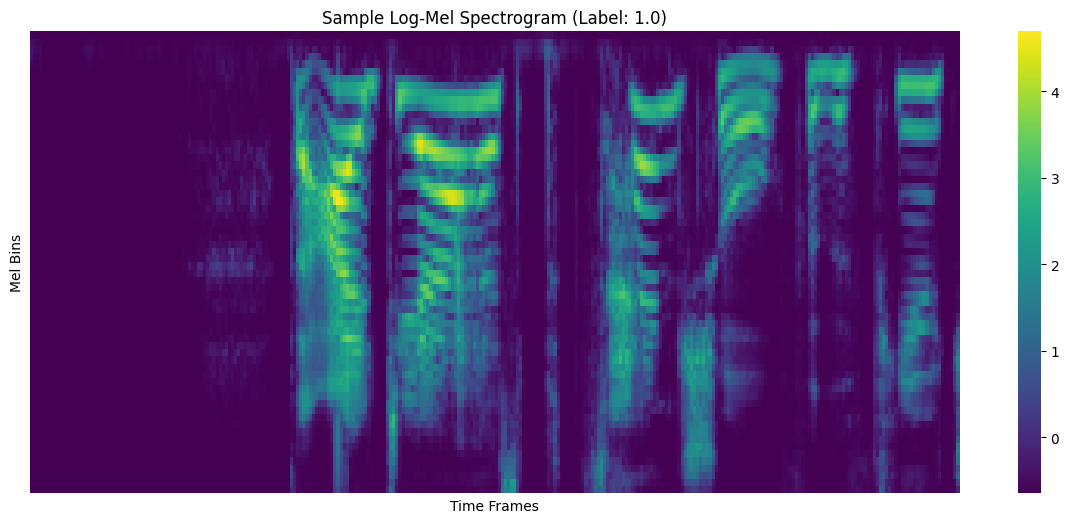

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get a sample from the training dataset
sample_idx = 0
sample = train_dataset[sample_idx]
sample_spectrogram = sample["features"].squeeze().cpu().numpy()

# Plot the spectrogram
plt.figure(figsize=(15, 6))
sns.heatmap(sample_spectrogram, cmap='viridis', yticklabels=False, xticklabels=False)
plt.title(f'Sample Log-Mel Spectrogram (Label: {sample["label"].item()})')
plt.xlabel('Time Frames')
plt.ylabel('Mel Bins')
plt.show()

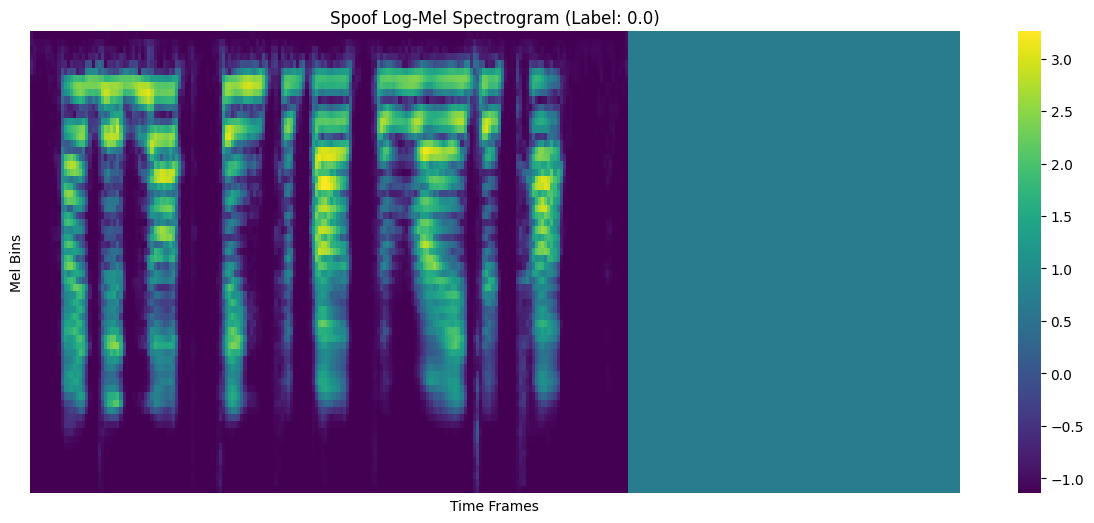

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Find a sample with label 0 (spoof)
sample = None
for i in range(len(train_dataset)):
    current_sample = train_dataset[i]
    if current_sample["label"].item() == 0:
        sample = current_sample
        break

if sample is None:
    print("No sample with label 0 found in the training dataset.")
else:
    sample_spectrogram = sample["features"].squeeze().cpu().numpy()

    # Plot the spectrogram
    plt.figure(figsize=(15, 6))
    sns.heatmap(sample_spectrogram, cmap='viridis', yticklabels=False, xticklabels=False)
    plt.title(f'Spoof Log-Mel Spectrogram (Label: {sample["label"].item()})')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Bins')
    plt.show()


In [ ]:
# Placeholder RCNN model definition (you'll need to define your actual RCNN architecture here)
class RCNN(nn.Module):
    def __init__(self, num_classes=1):
        super(RCNN, self).__init__()
        # Example architecture, replace with your actual RCNN layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(5, 5), padding=(2, 2))
        # self.conv2 = nn.Conv2d(32, 32, kernel_size=(5, 5), padding=(2, 2))
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        self.relu = nn.ReLU()

        # RNN part (LSTM here, modify as needed for your RCNN design)
        # Input to LSTM should be (batch_size, sequence_length, input_size)
        # After convolutions, features will be flattened across the frequency dimension
        # Let's assume after conv and pool, the feature map size is (N, C, H', W')
        # We'll treat W' as sequence_length, and C*H' as input_size for LSTM
        # This is a simplification; a full RCNN might have more sophisticated connections.
        self.lstm = nn.LSTM(input_size=32 * 32, hidden_size=128, batch_first=True)

        self.fc = nn.Linear(128, num_classes)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # CNN layers
        x = self.pool(self.relu(self.conv1(x)))
        # x = self.pool(self.relu(self.conv2(x)))
        # Reshape for RNN: (batch_size, channels * height, width) -> (batch_size, width, channels * height)
        # Assuming output from pool is (batch_size, 32, 32, 375) for 64 mels and 750 frames (approx)
        # If input_size is (1, 64, 750), after conv1 (1, 32, 64, 750), after pool (1, 32, 32, 375)
        # For LSTM, we need (batch_size, seq_len, features_per_step)
        batch_size, channels, height, width = x.size()
        x = x.permute(0, 3, 1, 2).contiguous().view(batch_size, width, channels * height)

        # RNN layers
        lstm_out, _ = self.lstm(x)

        # Take the output of the last time step
        x = lstm_out[:, -1, :]

        # Classifier
        x = self.fc(x)
        x = self.sigmoid(x)
        return x

# Initialize your exact model
model_rcnn = RCNN()

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_rcnn.to(device)

# Define Loss and Optimizer
criterion = torch.nn.BCELoss() # Binary Cross Entropy (since your model ends in Sigmoid)
optimizer = torch.optim.Adam(model_rcnn.parameters(), lr=0.01)

# --- TRAINING LOOP ---
epochs = 100

for epoch in range(epochs):
    model_rcnn.train() # Set model to training mode
    running_loss = 0.0

    for batch in train_loader:
        # 1. Get the batch of spectrograms and labels
        # features shape: [32, 1, 64, 750] (Batch, Channel, Mels, Time)
        features = batch["features"].to(device)

        # labels shape: [32]
        labels = batch["label"].to(device).unsqueeze(1) # reshape to [32, 1] to match model output

        # 2. Zero the gradients
        optimizer.zero_grad()

        # 3. Forward Pass: Feed Spectrograms to CNN -> RNN -> FC
        # outputs shape: [32, 1] (Probabilities between 0 and 1)
        outputs = model_rcnn(features)

        # 4. Calculate Loss
        loss = criterion(outputs, labels)

        # 5. Backward Pass (Calculate gradients)
        loss.backward()

        # 6. Update weights
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/40 - Loss: 0.6123
Epoch 2/40 - Loss: 0.5395
Epoch 3/40 - Loss: 0.5091
Epoch 4/40 - Loss: 0.5373
Epoch 5/40 - Loss: 0.4852
Epoch 6/40 - Loss: 0.4634
Epoch 7/40 - Loss: 0.4719
Epoch 8/40 - Loss: 0.4503
Epoch 9/40 - Loss: 0.4568
Epoch 10/40 - Loss: 0.4460
Epoch 11/40 - Loss: 0.4466
Epoch 12/40 - Loss: 0.4439
Epoch 13/40 - Loss: 0.4364
Epoch 14/40 - Loss: 0.4526
Epoch 15/40 - Loss: 0.4104
Epoch 16/40 - Loss: 0.4388
Epoch 17/40 - Loss: 0.4157
Epoch 18/40 - Loss: 0.4309
Epoch 19/40 - Loss: 0.4671
Epoch 20/40 - Loss: 0.4413
Epoch 21/40 - Loss: 0.4191
Epoch 22/40 - Loss: 0.4220
Epoch 23/40 - Loss: 0.4472
Epoch 24/40 - Loss: 0.4408
Epoch 25/40 - Loss: 0.4218
Epoch 26/40 - Loss: 0.4242
Epoch 27/40 - Loss: 0.4140
Epoch 28/40 - Loss: 0.4066
Epoch 29/40 - Loss: 0.4571
Epoch 30/40 - Loss: 0.4047
Epoch 31/40 - Loss: 0.3868
Epoch 32/40 - Loss: 0.3895
Epoch 33/40 - Loss: 0.3973
Epoch 34/40 - Loss: 0.3896
Epoch 35/40 - Loss: 0.4105
Epoch 36/40 - Loss: 0.3578
Epoch 37/40 - Loss: 0.3731
Epoch 38/4

### RCNN Model Prediction and Evaluation

In [ ]:
# 1. Create test_samples list
test_samples = load_samples_from_protocol(TEST_PROTO, TEST_DIR)

# 2. Create the Test Dataset
# We reuse the same log_mel_extractor to ensure consistent feature extraction
test_dataset = LogMelDataset(test_samples, extractor=log_mel_extractor)

# 3. Create the Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,     # Can be the same as train (or larger if GPU memory permits)
    shuffle=False,     # ⚠️ CRITICAL: Never shuffle test data!
    num_workers=2,
    pin_memory=True
)

In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, classification_report

def evaluate_rcnn_model(model, data_loader, device):
    """
    Evaluates the RCNN model on a given dataset and calculates EER, AUC, and Accuracy.
    """
    model_rcnn.eval()  # ⚠️ CRITICAL: Set model to evaluation mode (disables dropout, fixes batchnorm)

    all_predictions = []
    all_labels = []
    all_attack_ids = []

    # ⚠️ CRITICAL: Disable gradient calculation during testing
    with torch.no_grad():
        for batch in test_loader:
            # 1. Load data to GPU/CPU
            features = batch["features"].to(device)
            labels = batch["label"].to(device).unsqueeze(1)
            attack_ids = batch["attack_id"]

            # 2. Forward pass
            outputs = model_rcnn(features)

            # 3. Store results
            all_predictions.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_attack_ids.extend(attack_ids)

    # Flatten arrays for scikit-learn
    all_predictions = np.array(all_predictions).flatten()
    all_labels = np.array(all_labels).flatten()

    # ---------------------------------------------------------
    # CALCULATE METRICS
    # ---------------------------------------------------------

    # 1. ROC-AUC Score
    try:
        auc_score = roc_auc_score(all_labels, all_predictions)
    except ValueError:
        auc_score = float('nan') # Handles edge case if only one class is present in a tiny test batch

    # 2. Equal Error Rate (EER) Calculation
    # EER is the point on the ROC curve where the False Positive Rate (FPR) equals the False Negative Rate (FNR)
    fpr, tpr, thresholds = roc_curve(all_labels, all_predictions, pos_label=1)
    fnr = 1 - tpr

    # Find the threshold where FPR and FNR are closest
    eer_index = np.nanargmin(np.absolute((fnr - fpr)))
    eer = fpr[eer_index]
    optimal_threshold = thresholds[eer_index]

    # 3. Standard Accuracy (using 0.5 as standard threshold)
    binary_preds = (all_predictions >= 0.5).astype(int)
    accuracy = accuracy_score(all_labels, binary_preds)

    # Print Results
    print(f"--- Evaluation Results ---")
    print(f"ROC-AUC Score : {auc_score:.4f}")
    print(f"EER           : {eer * 100:.2f}% (Lower is better)")
    print(f"Accuracy      : {accuracy * 100:.2f}%")
    print(f"Optimal Thresh: {optimal_threshold:.4f}")
    print("\nClassification Report (at threshold=0.5):")
    print(classification_report(all_labels, binary_preds, target_names=["Spoof (0)", "Bonafide (1)"]))

    return eer, auc_score, accuracy, all_predictions, all_labels

In [ ]:
# Assuming you already defined 'device', 'model', and 'test_loader' from earlier

print("Starting evaluation on the Test Set...")

# Call the evaluation function
test_eer, test_auc, test_acc, preds, labels = evaluate_rcnn_model(
    model=model_rcnn,
    data_loader=test_loader,
    device=device
)

Starting evaluation on the Test Set...
--- Evaluation Results ---
ROC-AUC Score : 0.8452
EER           : 21.89% (Lower is better)
Accuracy      : 81.50%
Optimal Thresh: 0.4510

Classification Report (at threshold=0.5):
              precision    recall  f1-score   support

   Spoof (0)       0.95      0.83      0.89     63882
Bonafide (1)       0.31      0.64      0.42      7355

    accuracy                           0.82     71237
   macro avg       0.63      0.74      0.65     71237
weighted avg       0.89      0.82      0.84     71237



### Weighted Voting Classifier (Using Dev Data as Test Set)

We will now create a weighted voting classifier using the already trained `model_svm` and `model_rcnn`, and make predictions on the `dev_df` (which serves as our test data here).

This involves:

1.  **Obtaining SVM Predictions:** Directly using `model_svm.predict_proba` on `dev_df`.
2.  **Obtaining RCNN Predictions:** Using `model_rcnn` with the `dev_loader`.
3.  **Combining Probabilities:** Combining the predictions with weights `0.7` for SVM and `0.3` for RCNN.
4.  **Evaluating the Ensemble:** Calculating performance metrics (EER, FPR, Recall, Accuracy, ROC-AUC, and total prediction latency).

In [ ]:
import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, classification_report, confusion_matrix

# --- Helper function to get RCNN predictions without full evaluation ---
# This avoids re-printing evaluation reports and allows just getting raw probabilities.
def get_rcnn_predictions(model, data_loader, device):
    model.eval()  # Set model to evaluation mode
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            features = batch["features"].to(device)
            labels = batch["label"].to(device) # Keep as 1D numpy for direct comparison

            outputs = model(features)
            all_predictions.extend(outputs.cpu().numpy()) # Store raw probabilities
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_predictions).flatten(), np.array(all_labels).flatten()


# --- Step 1: Make SVM predictions and measure latency on dev_df ---
print("\n--- Making SVM predictions on dev_df ---")
# dev_df is already prepared and contains features for SVM
# dev_df_label contains the true labels
X_dev_svm = dev_df
y_true_dev = dev_df_label.values # True labels for evaluation

start_time_svm = time.time()
svm_probs = model_svm.predict_proba(X_dev_svm)[:, 1]
latency_svm = time.time() - start_time_svm

print(f"SVM prediction latency (on dev_df): {latency_svm:.4f} seconds")

# --- Step 2: Make RCNN predictions and measure latency on dev_loader ---
print("\n--- Making RCNN predictions on dev_loader ---")
# dev_loader is already defined (from cell cdda2d99) and suitable for RCNN
start_time_rcnn = time.time()
rcnn_probs, y_true_rcnn = get_rcnn_predictions(
    model=model_rcnn,
    data_loader=dev_loader,
    device=device
)
latency_rcnn = time.time() - start_time_rcnn

print(f"RCNN prediction latency (on dev_loader): {latency_rcnn:.4f} seconds")

# --- Step 3: Ensure labels align and set final true labels ---
# Both dev_df_label and y_true_rcnn should come from the same protocol order.
# It's good practice to verify or assume they are aligned if data loading was sequential.
if not np.array_equal(y_true_dev, y_true_rcnn):
    print("WARNING: True labels from SVM (dev_df) and RCNN (dev_loader) do not match order!")
    print("This could lead to incorrect ensemble evaluation. Please investigate data loading process.")
    true_labels = y_true_rcnn # Fallback, but investigate if this warning appears
else:
    print("True labels for SVM and RCNN dev sets are aligned.")
    true_labels = y_true_dev # Use either, as they are the same


# --- Step 4: Combine predictions ---
# User specified weights: model_svm*(0.7) & model_rcnn(0.3)
weight_svm = 0.7
weight_rcnn = 0.3
combined_probs = (svm_probs * weight_svm) + (rcnn_probs * weight_rcnn)
print("\nCombined predictions calculated.")

# --- Step 5: Evaluate Combined Model ---
print("\n--- Weighted Voting Classifier Evaluation (on Dev Data) ---")

start_time_ensemble_metrics = time.time()

# Calculate EER and optimal threshold for the combined model
fpr_combined, tpr_combined, thresholds_combined = roc_curve(true_labels, combined_probs, pos_label=1)
fnr_combined = 1 - tpr_combined

eer_index_combined = np.nanargmin(np.absolute((fnr_combined - fpr_combined)))
eer_combined = fpr_combined[eer_index_combined]
optimal_threshold_combined = thresholds_combined[eer_index_combined]

# Make binary predictions using the optimal threshold
combined_preds_binary = (combined_probs >= optimal_threshold_combined).astype(int)

# Calculate other metrics
auc_combined = roc_auc_score(true_labels, combined_probs)
accuracy_combined = accuracy_score(true_labels, combined_preds_binary)

# For FPR and Recall at optimal threshold, get confusion matrix
tn, fp, fn, tp = confusion_matrix(true_labels, combined_preds_binary).ravel()

# Handle potential ZeroDivisionError for FPR and Recall if a class has no true samples
fpr_at_optimal_threshold = fp / (fp + tn) if (fp + tn) > 0 else 0.0
recall_at_optimal_threshold = tp / (tp + fn) if (tp + fn) > 0 else 0.0

report_combined = classification_report(true_labels, combined_preds_binary, target_names=["Spoof (0)", "Bonafide (1)"])

latency_ensemble_metrics = time.time() - start_time_ensemble_metrics

print(f"Total Prediction Latency (SVM + RCNN): {latency_svm + latency_rcnn:.4f} seconds")
print(f"Latency (Ensemble metrics calculation): {latency_ensemble_metrics:.4f} seconds")
print("--------------------------------------------------")
print(f"ROC-AUC Score (Combined): {auc_combined:.4f}")
print(f"EER (Combined)           : {eer_combined * 100:.2f}%")
print(f"FPR (at optimal threshold): {fpr_at_optimal_threshold:.4f}")
print(f"Recall (at optimal threshold): {recall_at_optimal_threshold:.4f}")
print(f"Accuracy (Combined)      : {accuracy_combined * 100:.2f}%")
print(f"Optimal Threshold        : {optimal_threshold_combined:.4f}")
print("\nClassification Report (Combined, at optimal threshold):")
print(report_combined)



--- Making SVM predictions on dev_df ---
SVM prediction latency (on dev_df): 33.4172 seconds

--- Making RCNN predictions on dev_loader ---
RCNN prediction latency (on dev_loader): 178.6127 seconds
True labels for SVM and RCNN dev sets are aligned.

Combined predictions calculated.

--- Weighted Voting Classifier Evaluation (on Dev Data) ---
Total Prediction Latency (SVM + RCNN): 212.0299 seconds
Latency (Ensemble metrics calculation): 0.0303 seconds
--------------------------------------------------
ROC-AUC Score (Combined): 0.9992
EER (Combined)           : 0.43%
FPR (at optimal threshold): 0.0043
Recall (at optimal threshold): 0.9969
Accuracy (Combined)      : 99.59%
Optimal Threshold        : 0.3045

Classification Report (Combined, at optimal threshold):
              precision    recall  f1-score   support

   Spoof (0)       1.00      1.00      1.00     22296
Bonafide (1)       0.96      1.00      0.98      2548

    accuracy                           1.00     24844
   macro av